In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

### SVM

**SVM** doesn't just find any decision boundary — it finds the **optimal** one that maximizes the **margin** between classes.

| Model | Goal |
|-------|------|
| **Logistic Regression** | *"Find any line that separates the data"* |
| **SVM** | *"Find the line that gives the maximum possible gap between classes"* |

Imagine you have two groups of points on a piece of paper (**red** and **blue**), and you need to draw a line to separate them.

**The SVM approach:** Don't just draw any line — draw the line that gives you the **maximum possible gap** between the groups!


                Red Points                    Blue Points
    ×   ×   ×                    ●   ●   ●
      ×   ×   ×                ●   ●   ●
    ×   ×   ×                  ●   ●   ●
    
    [Margin] ←---LINE---→ [Margin]
    
    SVM finds the line with the WIDEST margin!


✅ Strengths

- ✅ Great with **small/medium datasets**
- ✅ Works with **complex patterns** (via kernels)
- ✅ **Memory efficient** — uses only support vectors


⚠️ Weaknesses

- ❌ **Slow on large datasets**
- ❌ **Sensitive to feature scaling**
- ❌ **Harder to interpret** than decision trees

**SVM** answers one question:

> *"Among all possible lines that separate the data, which one is BEST?"*

**The answer:** The line that **maximizes the margin**.


### SVM Kernels: Finding Non-Linear Boundaries

**SVM** can use different **kernels** to find non-linear decision boundaries:

| Kernel | When to Use | Decision Boundary |
|--------|-------------|-------------------|
| **Linear** | Linearly separable data | Straight line |
| **RBF (default)** | Most common, handles non-linear data | Curved boundaries |
| **Poly** | When data has polynomial relationships | Polynomial curves |
| **Sigmoid** | Neural network-like | S-shaped curves |

### The `C` Parameter in SVM

**Controls the trade-off**

| Small C | Large C |
|---------|---------|
| Wider margin | Narrower margin |
| More misclassifications allowed | Fewer misclassifications |
| Simpler model | More complex model |

### The `gamma` Parameter in SVM

**Only for RBF / Poly kernels**

Controls the **influence of individual training points**:

| Small gamma | Large gamma |
|-------------|-------------|
| Points have influence over a **larger area** | Points have influence over a **smaller area** |
| **Smooth** decision boundary | **Complex**, can **overfit** |
| Generalizes better | May fit noise |

⚠️ SVM is VERY Sensitive to Scale

SVM is **highly sensitive** to the scale of your features.

| Reason | Impact |
|--------|--------|
| **Distance-based** | SVM uses Euclidean distance to define margins |
| **Large-scale features** | Dominate the distance calculation |
| **Small-scale features** | Get ignored / overshadowed |

('scaler', StandardScaler()),  # ← CRITICAL!

### LinearSVC vs SVC
from sklearn.svm import LinearSVC  # Faster for large datasets

| Feature | `SVC(kernel='linear')` | `LinearSVC` |
|---------|------------------------|-------------|
| **Speed** | Slower | ✅ Faster |
| **Scalability** | Limited | ✅ Handles large datasets |
| **Kernel** | Any kernel | Linear only |
| **Implementation** | LibSVM | LibLinear |


When to Use LinearSVC

| Scenario | Recommendation |
|----------|----------------|
| **Large datasets (>10,000 samples)** | Use `LinearSVC` |
| **Many features** | Use `LinearSVC` |
| **Linear data** | Use `LinearSVC` |
| **Non-linear data** | Use `SVC(kernel='rbf')` |
| **Need probability estimates** | Use `SVC` with `probability=True` |


In [2]:
X, y = make_classification(
    n_samples=40,           # 40 points total
    n_features=2,           # 2 features (can plot in 2D)
    n_informative=2,        # Both features are useful
    n_redundant=0,          # No redundant features
    n_clusters_per_class=1, # One cluster per class
    random_state=42
)

X = np.vstack([X, [[1.5, 0.5], [-1.5, -0.5]]])  # Add outliers
y = np.hstack([y, [1, 0]])  # Labels for outliers

print("="*60)
print("SIMPLE 2D DATASET")
print("="*60)
print(f"Total points: {len(X)}")
print(f"Class 0 (Red): {sum(y==0)} points")
print(f"Class 1 (Blue): {sum(y==1)} points")

SIMPLE 2D DATASET
Total points: 42
Class 0 (Red): 20 points
Class 1 (Blue): 22 points


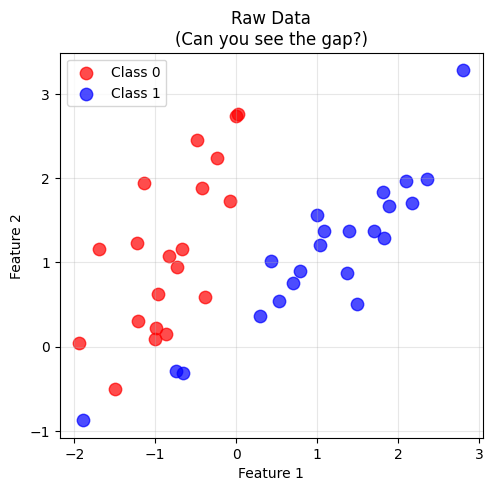

In [3]:
plt.figure(figsize=(12, 5))

# original data
plt.subplot(1, 2, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', s=80, alpha=0.7, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', s=80, alpha=0.7, label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Raw Data\n(Can you see the gap?)')
plt.legend()
plt.grid(True, alpha=0.3)

In [6]:
C_values = [0.1, 1, 10, 100]
models = {}

for i, C in enumerate(C_values):
    # Train SVM with RBF kernel
    svm = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    svm.fit(X, y)
    models[C] = svm
    
    print(f"\nSVM with C={C}:")
    print(f"  Support Vectors: {len(svm.support_vectors_)}")
    print(f"  Accuracy: {svm.score(X, y):.4f}")


SVM with C=0.1:
  Support Vectors: 40
  Accuracy: 0.9286

SVM with C=1:
  Support Vectors: 16
  Accuracy: 0.9286

SVM with C=10:
  Support Vectors: 9
  Accuracy: 0.9762

SVM with C=100:
  Support Vectors: 6
  Accuracy: 1.0000


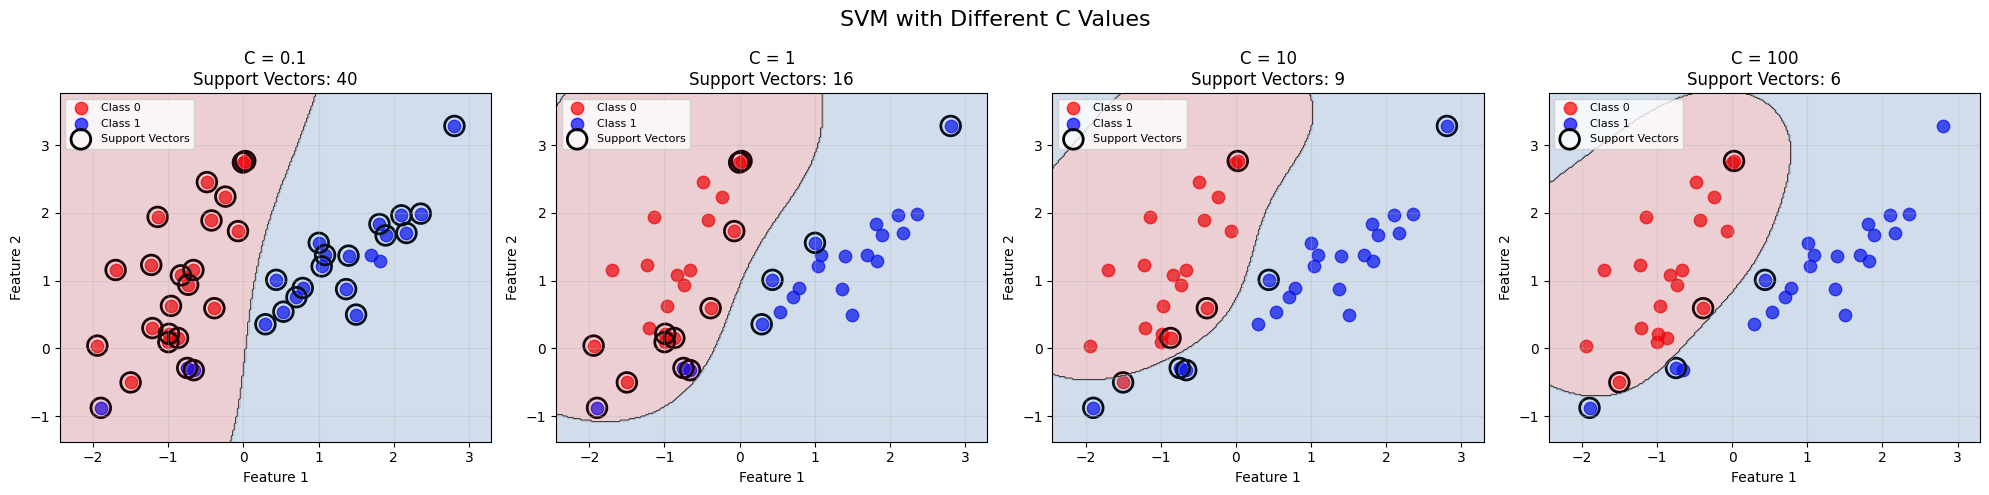

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (C, svm) in enumerate(models.items()):
    ax = axes[idx]
    
    # Plot data points
    ax.scatter(X[y==0, 0], X[y==0, 1], color='red', s=80, alpha=0.7, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', s=80, alpha=0.7, label='Class 1')
    
    # Highlight support vectors
    support_vectors = svm.support_vectors_
    ax.scatter(support_vectors[:, 0], support_vectors[:, 1], 
               s=200, facecolors='none', edgecolors='black', 
               linewidths=2, label='Support Vectors')
    
    # Create mesh for decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict on mesh
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdBu')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5, levels=[0])
    
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'C = {C}\nSupport Vectors: {len(svm.support_vectors_)}')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('SVM with Different C Values', fontsize=16)
plt.tight_layout()
plt.show()

| C Value | Margin | Misclassifications | Boundary | Risk |
|---------|--------|-------------------|----------|------|
| **0.1**  | Wide | More allowed | Very smooth | Underfitting |
| **1**  | Moderate | Few | Balanced | Good trade-off ✅ |
| **10**  | Narrow | Very few | Bending | Some overfitting |
| **100**  | Very narrow | None | Complex | Overfitting ❌ |